In [30]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *

In [31]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')




# SPECTRA = Spectrum(spectra_data, color_data, cigale_data)
# sfg_crit = SPECTRA.SFG_criteria(exclude=False)
# qso_crit    = SPECTRA.subtype_criteria(subtype='QSO', exclude=True)

# SPECTRA.subset(criteria=sfg_crit & qso_crit)
# # SPECTRA.shrink_dataset(20)
# SPECTRA.stack_data()
# SPECTRA.mask_bad()

In [32]:
spectra_data.info()
fastspecfit.info()

Filename: /Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     16   100638R x 4C   [K, D, D, D]   
  2  FLUX          1 ImageHDU         9   (7781, 1, 100638)   float64   
  3  INVERSE VARIANCE    1 ImageHDU         9   (7781, 1, 100638)   float64   
  4  MASK          1 ImageHDU        11   (7781, 1, 100638)   int32 (rescales to uint32)   
Filename: /Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     16   100639R x 4C   [K, D, D, D]   
  2  CONTINUUM     1 ImageHDU         8   (7781, 100639)   float32   
  3  SMOOTH CONTINUUM    1 ImageHDU         8   (7781, 100639)   float32   
  4  EMISSION      1 ImageHDU         8   (7781, 100639)   float32   


In [101]:
test_id = 39627812214146487


test_idx = np.where(fastspecfit[1].data['TARGETID']==test_id)[0][0]
print(fastspecfit[1].data['TARGETID'][test_idx])

39627812214146487


In [102]:
spectra_test_idx = np.where(spectra_data[1].data['TARGETID']==fastspecfit[1].data['TARGETID'][test_idx])[0][0]
print(spectra_data[1].data['TARGETID'][spectra_test_idx])


39627812214146487


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_29375/2306987461.py:3: RuntimeWarning: divide by zero encountered in divide
  sigma = np.array(np.sqrt(1/ivar))


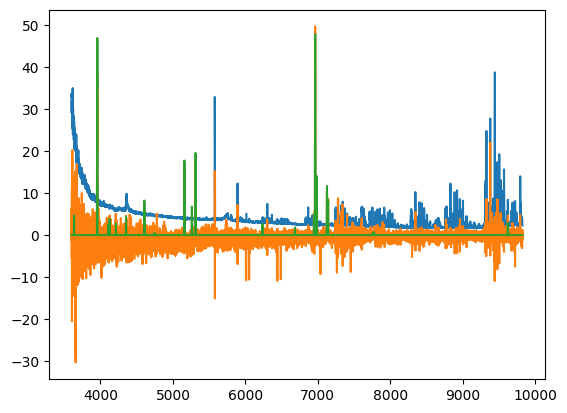

In [ ]:
coadd   = spectra_data[2].data[spectra_test_idx, 0, :]
ivar    = spectra_data[3].data[spectra_test_idx, 0, :]
sigma = np.array(np.sqrt(1/ivar))


conti = fastspecfit[2].data[test_idx]
emline = fastspecfit[4].data[test_idx]

# plt.plot(conti)

plt.plot(desi_wavelength, 3*sigma)
plt.plot(desi_wavelength, coadd-conti)
plt.plot(desi_wavelength, emline)
plt.xlim(left=8100, right=8250)
plt.show()